<a href="https://www.kaggle.com/code/sonawanelalitsunil/startup-success-insights-2019-23-ml-64-9?scriptVersionId=229920609" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/reddit-data-for-factors-influencing-startup/Reddit Data.csv


## Title: Startup Success Insights (Reddit, 2019-23)

#### Description: Key factors influencing startup success based on Reddit discussions from 2019 to 2023.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/reddit-data-for-factors-influencing-startup/Reddit Data.csv')

In [3]:
df.head()

,Title,Body,Upvotes
0,7 Inspiring Micro-Startup Success Stories to F...,"In this article, we embark on a fascinating jo...",5
1,7 Inspiring Micro-Startup Success Stories to F...,"In this article, we embark on a fascinating jo...",1
2,"I went from art-school dropout to 12k/month, b...","Hey there! so like it says in the title, I dro...",403
3,What are the key factors a successful entrepre...,Hi reddit. I am working on what I need to do t...,2
4,15 lessons from our first $15 million in recur...,"Hey Reddit,\n\nI wrote this post for my blog, ...",900


In [4]:
df.tail()

,Title,Body,Upvotes
562,Traction is no longer king. Having the right t...,"This applies for any founder, but is particula...",196
563,How This Letter Made $2 Billion Dollars for Th...,"It's 1975.\n\nA copywriter, Martin Conroy, sit...",1061
564,YC startup: Our app was so bad it went viral,I’m one of the cofounders of [Superpowered](ht...,351
565,"Some ""lessons"" from someone who's sold $10m on...","Hi there, I am about 7 years into my entrepren...",494
566,I’m SICK of all these “Success Stories” Online,"In 2023, everyone is a millionaire.\n\nEvery s...",162


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    567 non-null    object
 1   Body     567 non-null    object
 2   Upvotes  567 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 13.4+ KB


In [6]:
df.describe()

,Upvotes
count,567.000000
mean,378.991182
std,698.308966
min,0.000000
25%,3.000000
50%,70.000000
75%,556.000000
max,7927.000000


In [7]:
df.isnull().sum()

Title      0
Body       0
Upvotes    0
dtype: int64

In [8]:
df.shape

(567, 3)

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Title      object
Body       object
Upvotes     int64
dtype: object

In [11]:
df.columns

Index(['Title', 'Body', 'Upvotes'], dtype='object')

## Data visualizations

In [12]:
from wordcloud import WordCloud

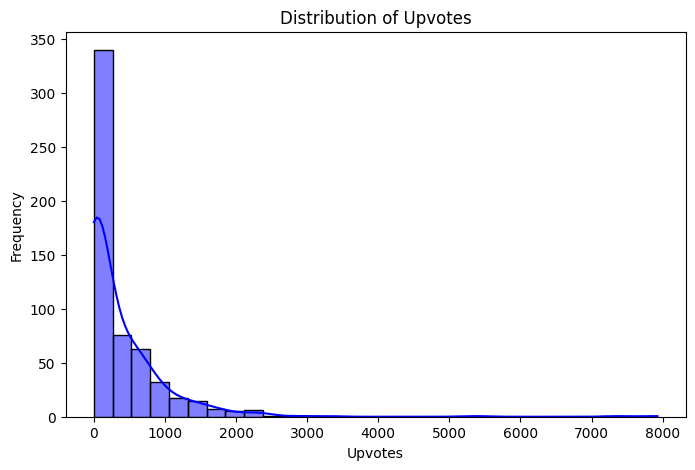

In [13]:
# 1. Upvote Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Upvotes'], bins=30, kde=True, color='blue')
plt.title('Distribution of Upvotes')
plt.xlabel('Upvotes')
plt.ylabel('Frequency')
plt.show()

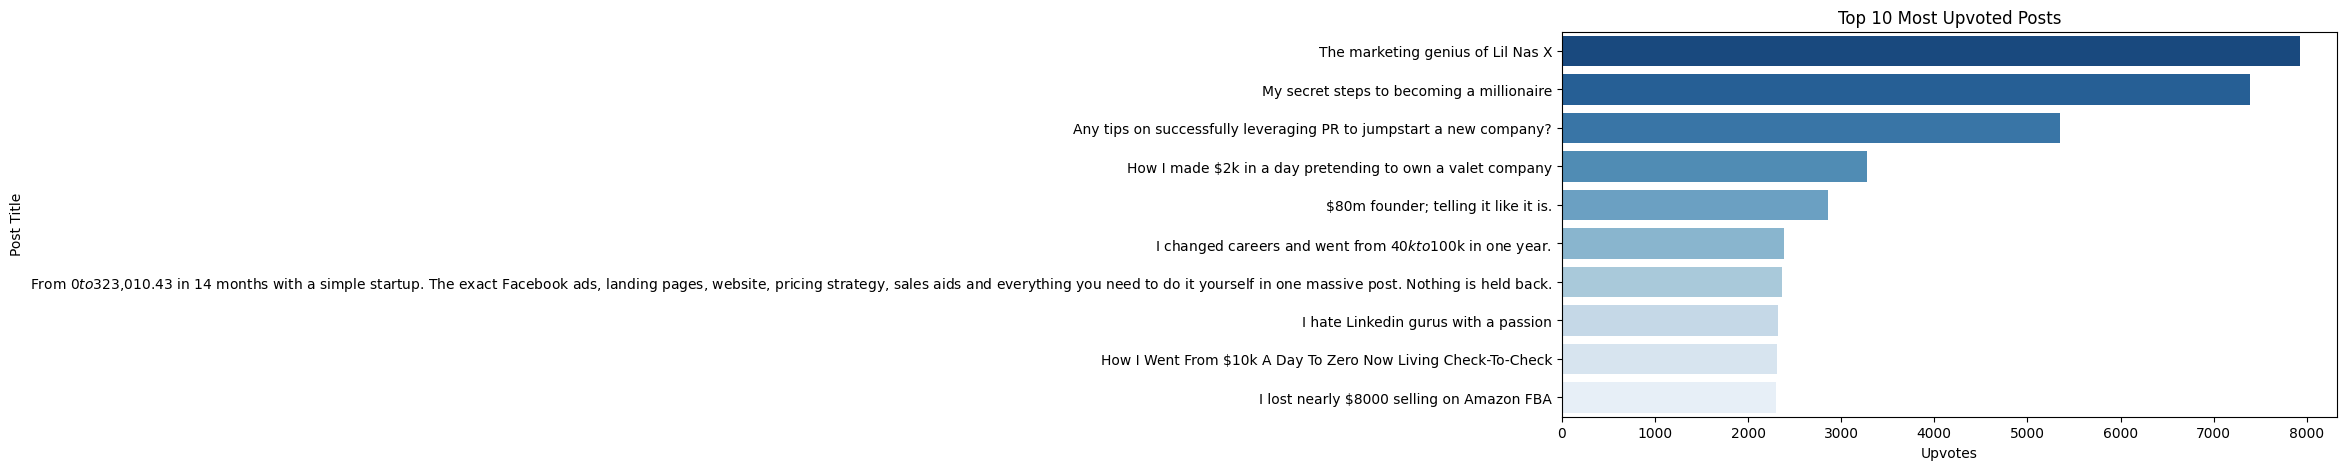

In [14]:
top_posts = df.nlargest(10, 'Upvotes')
plt.figure(figsize=(10, 5))
sns.barplot(y=top_posts['Title'], x=top_posts['Upvotes'], palette='Blues_r')
plt.title('Top 10 Most Upvoted Posts')
plt.xlabel('Upvotes')
plt.ylabel('Post Title')
plt.show()

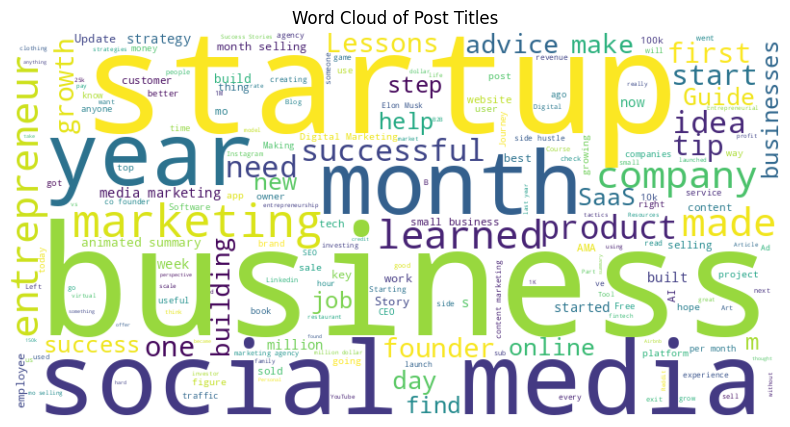

In [15]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df['Title'].dropna()))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Post Titles')
plt.show()

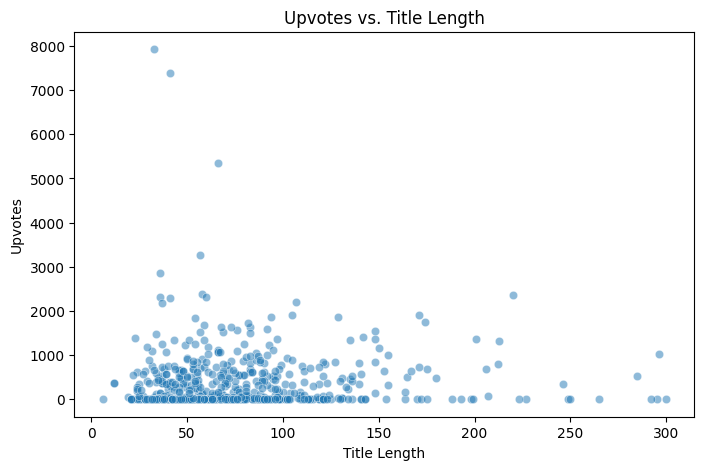

In [16]:
df['Title_Length'] = df['Title'].apply(lambda x: len(str(x)))
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Title_Length'], y=df['Upvotes'], alpha=0.5)
plt.title('Upvotes vs. Title Length')
plt.xlabel('Title Length')
plt.ylabel('Upvotes')
plt.show()

In [17]:
if 'Sentiment' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df['Sentiment'], y=df['Upvotes'], palette='coolwarm')
    plt.title('Sentiment vs. Upvotes')
    plt.xlabel('Sentiment')
    plt.ylabel('Upvotes')
    plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [19]:
# Label Encoding
df['Title_Encoded'] = LabelEncoder().fit_transform(df['Title'].astype(str))
df['Body_Encoded'] = LabelEncoder().fit_transform(df['Body'].astype(str))

In [20]:
# Features and Target
X = df[['Title_Encoded', 'Body_Encoded']]
y = df['Upvotes'] > df['Upvotes'].median()  # Binary classification (High vs Low Upvotes)

In [21]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# ML Models and Evaluation
models = {
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier()
}

In [23]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    results[name] = accuracy

In [24]:
# Print Accuracy Results
print("\nModel Accuracy Results:")
for model, acc in results.items():
    print(f"{model}: {acc:.2f}%")


Model Accuracy Results:
Random Forest: 63.16%
Support Vector Machine: 54.39%
Logistic Regression: 55.26%
K-Nearest Neighbors: 52.63%
Naive Bayes: 55.26%
Decision Tree: 57.89%


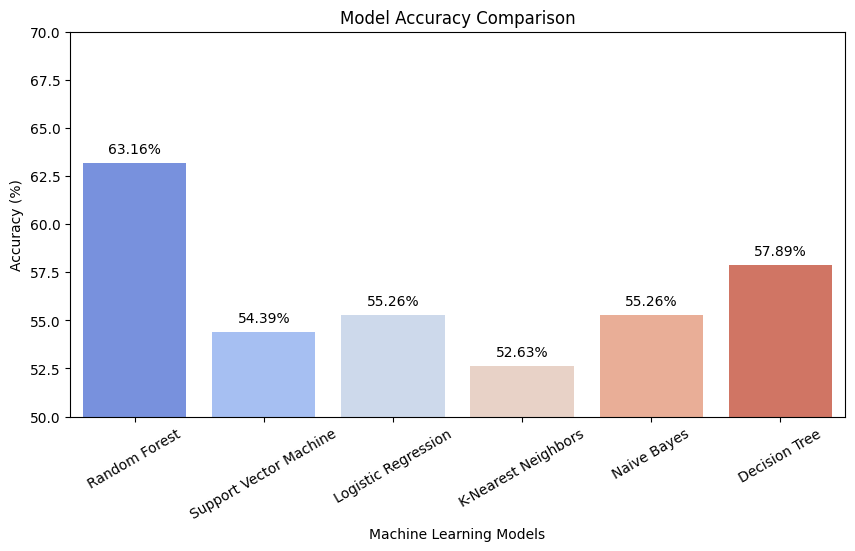

In [25]:
# Accuracy Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy (%)')
plt.ylim(50, 70)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10)
plt.xticks(rotation=30)
plt.show()

## Thank you...pls upvote!!!